# MQT DD Sim

In [1]:
from qiskit import QuantumCircuit
from mqt import ddsim

circ = QuantumCircuit(3)
circ.h(0)
circ.cx(0, 1)
circ.cx(0, 2)

print(circ.draw(fold=-1))

backend = ddsim.DDSIMProvider().get_backend("qasm_simulator")

job = backend.run(circ, shots=10000)
counts = job.result().get_counts(circ)
print(counts)

     ┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘
{'0': 5037, '111': 4963}


## Quick Start

a

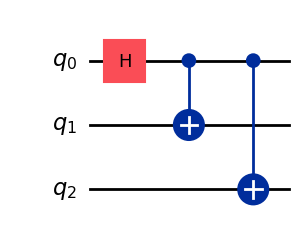

In [2]:
from qiskit.circuit import QuantumCircuit

circ = QuantumCircuit(3)
circ.h(0)
circ.cx(0, 1)
circ.cx(0, 2)

circ.draw(output="mpl", style="iqp")



In [3]:
from mqt import ddsim

provider = ddsim.DDSIMProvider()
backend = provider.get_backend("qasm_simulator")

job = backend.run(circ, shots=10000)
counts = job.result().get_counts(circ)
print(counts)

{'0': 4952, '111': 5048}


## Simulators

In [4]:
from pathlib import Path

qasm = """
OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];
"""
filename = "bell.qasm"
with Path(filename).open("w", encoding="utf-8") as f:
    f.write(qasm)

In [5]:
from mqt.core import load

from mqt.ddsim import CircuitSimulator

# create a CircuitSimulator object
qc = load(filename)
sim = CircuitSimulator(qc)

# run the simulation
result = sim.simulate(shots=1024)

# print the result
print(result)

{'00': 482, '11': 542}


In [6]:
import numpy as np

# get the final DD
dd = sim.get_constructed_dd()
# transform the DD to a vector
vec = dd.get_vector()
# transform to a numpy array (without copying)
sv = np.array(vec, copy=False)
print(sv)

[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


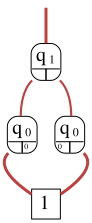

In [7]:
import graphviz

dot = dd.to_dot(colored=True, edge_labels=False, classic=False, memory=False, format_as_polar=True)

graphviz.Source(source=dot)

In [8]:
# clean up
Path(filename).unlink()

### Using QuantumCircuit from Qiskit

In [9]:
from qiskit import QuantumCircuit

# create the Bell circuit
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

# create a CircuitSimulator object
circ = load(qc)
sim = CircuitSimulator(circ)

# run the simulation
result = sim.simulate(shots=1024)

# print the result
print(result)

{'00': 532, '11': 492}


### Simulating with mid-circuit measurements

In [10]:
import locale
from pathlib import Path

qasm = """
OPENQASM 3.0;
include "stdgates.inc";

// counting register
qubit[1] q;

// eigenstate register
qubit[1] psi;

// classical registers
bit[3] c;

// initialize eigenstate psi = |1>
x psi;

// start by computing LSB c_0
h q;
cp(4 * (3*pi/8)) psi, q;
h q;
c[0] = measure q[0];

// reset counting qubit and compute middle bit c_1
reset q;
h q;
cp(2 * (3*pi/8)) psi, q;
if (c == 1) p(-pi/2) q;
h q;
c[1] = measure q[0];

// reset counting qubit and compute MSB c_2
reset q;
h q;
cp(1 * (3*pi/8)) psi, q;
if (c == 1) p(1 * -pi/4) q;
if (c == 2) p(2 * -pi/4) q;
if (c == 3) p(3 * -pi/4) q;
h q;
c[2] = measure q[0];
"""
filename = "iqpe.qasm"
with Path(filename).open("w", encoding=locale.getpreferredencoding(False)) as f:
    f.write(qasm)

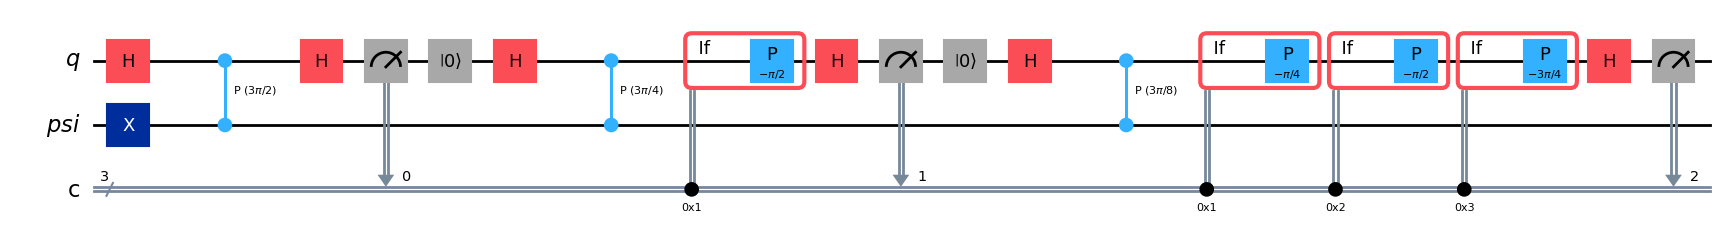

In [11]:
from qiskit import qasm3

qc = qasm3.loads(qasm)
qc.draw(output="mpl", style="iqp")

In [13]:
from mqt.core import load

from mqt.ddsim import CircuitSimulator

# create a CircuitSimulator object
circ = load(filename)
sim = CircuitSimulator(circ)

# run the simulation
result = sim.simulate(shots=1024)

# print the result
print(result)

{'000': 54, '001': 431, '010': 393, '011': 59, '100': 20, '101': 23, '110': 21, '111': 23}


In [15]:
# clean up
Path(filename).unlink()

FileNotFoundError: [Errno 2] No such file or directory: 'iqpe.qasm'

### Usage as Qiskit Backend

In [16]:
from mqt.ddsim import DDSIMProvider

provider = DDSIMProvider()

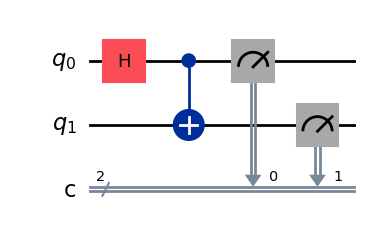

In [17]:
from qiskit import QuantumCircuit

# create the Bell circuit
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

qc.draw(output="mpl", style="iqp")

In [19]:
provider.backends()

In [28]:
# get the backend
# backend = provider.get_backend("qasm_simulator")
backend = provider.get_backend("stochastic_dd_simulator")
backend = provider.get_backend("density_matrix_dd_simulator")

# submit the job
job = backend.run(qc, shots=10000)

# get the result
result = job.result()
print(result.get_counts())

{'00': 5038, '01': 268, '10': 258, '11': 4436}


In [30]:
# get the backend
backend = provider.get_backend("hybrid_statevector_simulator")

# submit the job
job = backend.run(qc)

# get the result
result = job.result()
print(result.get_statevector())

[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


## Noise-aware Simulator